In [ ]:
!pip install diffusers transformers accelerate --quiet
!pip install datasets --quiet
!pip install ftfy regex tqdm --quiet
!pip install git+https://github.com/openai/CLIP.git --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

import os
import gc
import torch
import clip
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from torchvision.transforms.functional import to_pil_image
import json
import time
from PIL import Image

env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


In [ ]:
import time
start = time.time()
# Create a directory to store the dataset
!mkdir -p coco_dataset/images coco_dataset/annotations

# Download 2017 train images
!wget http://images.cocodataset.org/zips/train2017.zip -P coco_dataset/
!unzip -q coco_dataset/train2017.zip -d coco_dataset/images/

# Download 2017 validation images (optional)
!wget http://images.cocodataset.org/zips/val2017.zip -P coco_dataset/
!unzip -q coco_dataset/val2017.zip -d coco_dataset/images/

# Download annotations (includes captions)
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P coco_dataset/
!unzip -q coco_dataset/annotations_trainval2017.zip -d coco_dataset/annotations/

end = time.time()
print(f"Time taken: {end - start:.2f} seconds")

--2025-04-22 20:44:16--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.25.174, 54.231.197.73, 52.217.107.140, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.25.174|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘coco_dataset/train2017.zip’

train2017.zip       100%[===================>]  18.01G   119MB/s    in 3m 26s  

2025-04-22 20:47:43 (89.3 MB/s) - ‘coco_dataset/train2017.zip’ saved [19336861798/19336861798]

--2025-04-22 20:49:41--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.8.211, 16.15.193.212, 16.15.185.195, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.8.211|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘coco_dataset/val2017.zip’

val2017.zip         1

In [ ]:
def prepare_coco_caption_file(annotation_path, output_json, max_captions=None):
    import json

    with open(annotation_path, "r") as f:
        annotations = json.load(f)

    image_id_to_file = {img["id"]: img["file_name"] for img in annotations["images"]}
    pairs = []

    for ann in annotations["annotations"]:
        image_id = ann["image_id"]
        caption = ann["caption"]
        file_name = image_id_to_file.get(image_id)
        if file_name:
            pairs.append({
                "file_name": file_name,
                "caption": caption
            })
        if max_captions and len(pairs) >= max_captions:
            break

    with open(output_json, "w") as f:
        json.dump(pairs, f, indent=2)

    print(f"✅ Saved {len(pairs)} image-caption pairs to {output_json}")


In [ ]:
start = time.time()
prepare_coco_caption_file(
    annotation_path="coco_dataset/annotations/annotations/captions_train2017.json",
    output_json="coco_train_captions_cleaned.json",
    max_captions=None  # or 30000
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

✅ Saved 591753 image-caption pairs to coco_train_captions_cleaned.json
Time taken: 3.43 seconds


In [ ]:
start = time.time()
prepare_coco_caption_file(
    annotation_path="coco_dataset/annotations/annotations/captions_val2017.json",
    output_json="coco_val_captions_cleaned.json",
    max_captions=None  # or 30000
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

✅ Saved 25014 image-caption pairs to coco_val_captions_cleaned.json
Time taken: 0.13 seconds


In [ ]:
import os
import json
from PIL import Image
from tqdm import tqdm

def clean_caption_file(caption_file, image_folder, output_file):
    """
    Cleans a COCO-style caption file by:
    - Removing entries with missing image files
    - Skipping unreadable or corrupt images
    - Ignoring empty or whitespace-only captions
    """
    with open(caption_file, "r") as f:
        data = json.load(f)

    cleaned = []
    skipped = 0

    for item in tqdm(data, desc=f"Verifying {caption_file}"):
        image_path = os.path.join(image_folder, item["file_name"])

        if not os.path.exists(image_path):
            skipped += 1
            continue

        try:
            with Image.open(image_path) as img:
                img.verify()  # Does not load into memory; just checks integrity
        except Exception:
            skipped += 1
            continue

        if item["caption"].strip() == "":
            skipped += 1
            continue

        cleaned.append(item)

    with open(output_file, "w") as f:
        json.dump(cleaned, f, indent=2)

    print(f"✅ {len(cleaned)} valid image-caption pairs saved to '{output_file}'")
    print(f"⚠️ {skipped} entries skipped due to missing/broken images or empty captions")

In [ ]:
clean_caption_file(
    caption_file="coco_train_captions_cleaned.json",
    image_folder="coco_dataset/images/train2017",
    output_file="coco_train_cleaned_verified.json"
)

Verifying coco_train_captions_cleaned.json: 100%|██████████| 591753/591753 [00:41<00:00, 14420.26it/s]


✅ 591753 valid image-caption pairs saved to 'coco_train_cleaned_verified.json'
⚠️ 0 entries skipped due to missing/broken images or empty captions


In [ ]:
clean_caption_file(
    caption_file="coco_val_captions_cleaned.json",
    image_folder="coco_dataset/images/val2017",
    output_file="coco_val_cleaned_verified.json"
)

Verifying coco_val_captions_cleaned.json: 100%|██████████| 25014/25014 [00:01<00:00, 14555.06it/s]

✅ 25014 valid image-caption pairs saved to 'coco_val_cleaned_verified.json'
⚠️ 0 entries skipped due to missing/broken images or empty captions


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from transformers import CLIPTokenizer, CLIPTextModel

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

In [ ]:
import os
import json
import torch
from tqdm import tqdm
from transformers import CLIPTokenizer, CLIPTextModel

def generate_clip_text_embeddings(
    caption_json_path,
    output_dir,
    batch_size=16,
    part_size=10000,
    model_name="openai/clip-vit-base-patch32"
):
    """
    Generates and saves CLIP text embeddings from COCO-style cleaned JSON.
    """
    # Load cleaned caption data
    with open(caption_json_path, "r") as f:
        data = json.load(f)

    captions = [entry["caption"] for entry in data]

    # Setup CLIP model (lighter version)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = CLIPTokenizer.from_pretrained(model_name)
    text_encoder = CLIPTextModel.from_pretrained(model_name).to(device)

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    text_embeddings = []
    part_idx = 0
    total_saved = 0

    # Loop through data in batches
    progress = tqdm(range(0, len(captions), batch_size), desc=f"Embedding {os.path.basename(caption_json_path)}")
    for i in progress:
        captions_batch = captions[i:i+batch_size]

        try:
            tokens = tokenizer(captions_batch, padding="max_length", truncation=True, return_tensors="pt").to(device)
            with torch.no_grad():
                text_features = text_encoder(**tokens).last_hidden_state  # [B, 77, 768]
                text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            text_embeddings.append(text_features.cpu())

            # Save part
            if len(text_embeddings) * batch_size >= part_size:
                text_tensor = torch.cat(text_embeddings, dim=0)
                save_path = os.path.join(output_dir, f"text_embeddings_part_{part_idx}.pt")
                torch.save(text_tensor, save_path)
                print(f"💾 Saved {text_tensor.shape} to {save_path}")
                total_saved += text_tensor.shape[0]
                part_idx += 1
                text_embeddings = []

        except Exception as e:
            print(f"⚠️ Batch at index {i} failed: {e}")
            continue

    # Save any remaining
    if text_embeddings:
        text_tensor = torch.cat(text_embeddings, dim=0)
        save_path = os.path.join(output_dir, f"text_embeddings_part_{part_idx}.pt")
        torch.save(text_tensor, save_path)
        print(f"💾 Saved {text_tensor.shape} to {save_path}")
        total_saved += text_tensor.shape[0]

    print(f"✅ Total embeddings saved: {total_saved}")

In [ ]:
with open("coco_train_cleaned_verified.json", "r") as f:
    data = json.load(f)

mini_60k = data[:75000]

with open("coco_train_75k.json", "w") as f:
    json.dump(mini_60k, f, indent=2)

print(f"✅ Saved 75,000 samples to coco_train_75k.json")

✅ Saved 75,000 samples to coco_train_75k.json


In [ ]:
start = time.time()
# ✅ Example usage for train
generate_clip_text_embeddings(
    caption_json_path="coco_train_75k.json",           # or val
    output_dir="clip_embeddings_train_l14",            # new folder to separate from old
    batch_size=16,
    part_size=60000,
    model_name="openai/clip-vit-large-patch14"
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Embedding coco_train_75k.json:  80%|████████  | 3754/4688 [02:11<36:20,  2.33s/it]

💾 Saved torch.Size([60000, 77, 768]) to clip_embeddings_train_l14/text_embeddings_part_0.pt


Embedding coco_train_75k.json: 100%|██████████| 4688/4688 [02:32<00:00, 30.67it/s]


💾 Saved torch.Size([15000, 77, 768]) to clip_embeddings_train_l14/text_embeddings_part_1.pt
✅ Total embeddings saved: 75000
Time taken: 162.46 seconds


In [ ]:
# %reset -f

In [ ]:
# ✅ Example usage for val
start = time.time()
generate_clip_text_embeddings(
    caption_json_path="coco_val_cleaned_verified.json",
    output_dir="clip_embeddings_val_l14",
    batch_size=16,
    part_size=60000,
    model_name="openai/clip-vit-large-patch14"
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Embedding coco_val_cleaned_verified.json: 100%|██████████| 1564/1564 [00:35<00:00, 43.90it/s]


💾 Saved torch.Size([25014, 77, 768]) to clip_embeddings_val_l14/text_embeddings_part_0.pt
✅ Total embeddings saved: 25014
Time taken: 54.23 seconds


In [ ]:
from diffusers import AutoencoderKL
from torchvision import transforms
from PIL import Image
import torch, json, os
from tqdm import tqdm

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
def generate_vae_latents(
    caption_json_path,
    image_base_folder,
    output_dir,
    batch_size=1,
    part_size=10000,
    model_path="CompVis/stable-diffusion-v1-4"
):
    # Load the cleaned JSON with file names
    with open(caption_json_path, "r") as f:
        data = json.load(f)

    image_paths = [os.path.join(image_base_folder, item["file_name"]) for item in data]

    # Load VAE and preprocessing pipeline
    device = "cuda" if torch.cuda.is_available() else "cpu"
    vae = AutoencoderKL.from_pretrained(model_path, subfolder="vae").to(device).eval()

    preprocess = transforms.Compose([
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    os.makedirs(output_dir, exist_ok=True)

    latents = []
    part_idx = 0
    total_saved = 0

    for i, path in enumerate(tqdm(image_paths, desc="Encoding VAE latents")):
        try:
            img = Image.open(path).convert("RGB")
            img_tensor = preprocess(img).unsqueeze(0).to(device)

            with torch.no_grad():
                latent = vae.encode(img_tensor).latent_dist.sample() * 0.18215

            latents.append(latent.cpu())

            if len(latents) >= part_size:
                latents_tensor = torch.cat(latents)
                torch.save(latents_tensor, os.path.join(output_dir, f"vae_latents_part_{part_idx}.pt"))
                print(f"💾 Saved {latents_tensor.shape} to vae_latents_part_{part_idx}.pt")
                total_saved += latents_tensor.shape[0]
                latents = []
                part_idx += 1

        except Exception as e:
            print(f"⚠️ Skipping {path}: {e}")
            continue

    if latents:
        latents_tensor = torch.cat(latents)
        torch.save(latents_tensor, os.path.join(output_dir, f"vae_latents_part_{part_idx}.pt"))
        print(f"💾 Saved {latents_tensor.shape} to vae_latents_part_{part_idx}.pt")
        total_saved += latents_tensor.shape[0]

    print(f"✅ Total VAE latents saved: {total_saved}")

In [ ]:
import time

In [ ]:
start = time.time()
generate_vae_latents(
    caption_json_path="coco_train_75k.json",
    image_base_folder="coco_dataset/images/train2017",
    output_dir="vae_latents_train",
    batch_size=8,
    part_size=60000
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Encoding VAE latents:  80%|████████  | 60005/75000 [16:02<17:29, 14.28it/s]

💾 Saved torch.Size([60000, 4, 32, 32]) to vae_latents_part_0.pt


Encoding VAE latents: 100%|██████████| 75000/75000 [20:03<00:00, 62.30it/s]


💾 Saved torch.Size([15000, 4, 32, 32]) to vae_latents_part_1.pt
✅ Total VAE latents saved: 75000
Time taken: 1204.59 seconds


In [ ]:
start = time.time()
generate_vae_latents(
    caption_json_path="coco_val_cleaned_verified.json",
    image_base_folder="coco_dataset/images/val2017",
    output_dir="vae_latents_val",
    batch_size=8,
    part_size=60000  # or however many you have in val
)
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Encoding VAE latents: 100%|██████████| 25014/25014 [06:31<00:00, 63.84it/s]


💾 Saved torch.Size([25014, 4, 32, 32]) to vae_latents_part_0.pt
✅ Total VAE latents saved: 25014
Time taken: 392.67 seconds


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import os

class LDMText2ImageDataset(Dataset):
    def __init__(self, latents_dir, embeddings_dir):
        self.latent_tensors = self._load_all_parts(latents_dir)
        self.embedding_tensors = self._load_all_parts(embeddings_dir)

        assert len(self.latent_tensors) == len(self.embedding_tensors), \
            f"Mismatch: {len(self.latent_tensors)} latents vs {len(self.embedding_tensors)} embeddings"

    def _load_all_parts(self, folder):
        all_parts = sorted(
            [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".pt")]
        )
        all_data = [torch.load(p) for p in all_parts]
        return torch.cat(all_data, dim=0)

    def __len__(self):
        return len(self.latent_tensors)

    def __getitem__(self, idx):
        return {
            "latent": self.latent_tensors[idx],
            "embedding": self.embedding_tensors[idx]
        }

In [ ]:
start = time.time()
# ✅ Example: Load the dataset and create a DataLoader
train_dataset = LDMText2ImageDataset(
    latents_dir="vae_latents_train",
    embeddings_dir="clip_embeddings_train_l14"
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Print one sample to confirm
sample = next(iter(train_loader))
print("Latent shape:", sample["latent"].shape)        # [B, 4, 32, 32]
print("Text embedding shape:", sample["embedding"].shape)  # [B, 77, 768] or [B, 768] depending on your embeddings
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Latent shape: torch.Size([32, 4, 32, 32])
Text embedding shape: torch.Size([32, 77, 768])
Time taken: 14.68 seconds


In [ ]:
# ✅ Example: Load the dataset and create a DataLoader
start = time.time()
val_dataset = LDMText2ImageDataset(
    latents_dir="vae_latents_val",
    embeddings_dir="clip_embeddings_val_l14"
)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

# Print one sample to confirm
sample = next(iter(val_loader))
print("Latent shape:", sample["latent"].shape)        # [B, 4, 32, 32]
print("Text embedding shape:", sample["embedding"].shape)  # [B, 77, 768] or [B, 768] depending on your embeddings
stop = time.time()
print(f"Time taken: {stop - start:.2f} seconds")

Latent shape: torch.Size([32, 4, 32, 32])
Text embedding shape: torch.Size([32, 77, 768])
Time taken: 26.18 seconds


In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from diffusers import UNet2DConditionModel, DDPMScheduler
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.optim.lr_scheduler import CosineAnnealingLR

In [ ]:
# ✅ Initialize UNet
device = "cuda" if torch.cuda.is_available() else "cpu"
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet").to(device).train()

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

In [ ]:
# ✅ Noise scheduler + optimizer
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
noise_scheduler.set_timesteps(1000)

optimizer = AdamW(unet.parameters(), lr=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=5)
mse_loss = nn.MSELoss()

Epoch 1:   0%|          | 1/2344 [00:01<53:55,  1.38s/it]

[Epoch 1 | Step 0] Train Loss: 0.1599


Epoch 1:   0%|          | 11/2344 [00:08<26:28,  1.47it/s]

[Epoch 1 | Step 10] Train Loss: 0.1253


Epoch 1:   1%|          | 21/2344 [00:14<26:06,  1.48it/s]

...

[Epoch 5 | Step 2330] Train Loss: 0.1085


Epoch 5: 100%|█████████▉| 2341/2344 [26:25<00:02,  1.48it/s]

[Epoch 5 | Step 2340] Train Loss: 0.1107


Epoch 5: 100%|██████████| 2344/2344 [26:27<00:00,  1.48it/s]


✅ Epoch 5 Avg Train Loss = 0.1341
🧪 Epoch 5 Avg Validation Loss = 0.1367
📦 Saved model at epoch 5


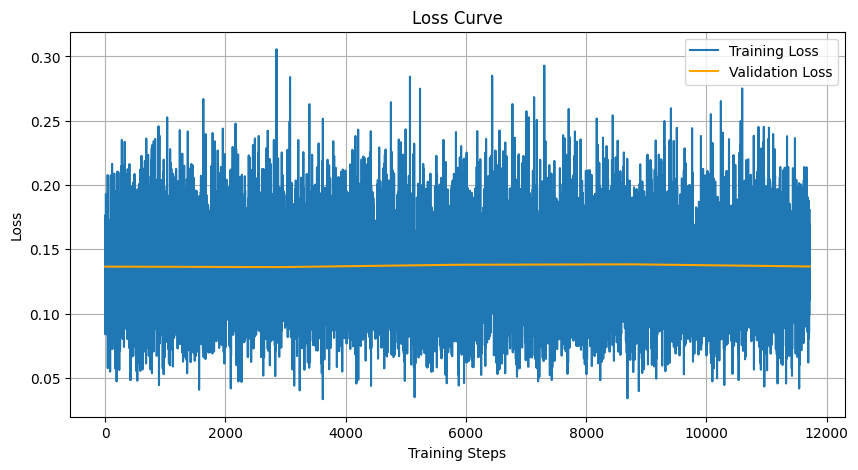

In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from diffusers import UNet2DConditionModel, DDPMScheduler
import matplotlib.pyplot as plt
from tqdm import tqdm


# ✅ Tracking
train_losses = []
val_losses = []
best_val_loss = float("inf")
num_epochs = 5

for epoch in range(num_epochs):
    unet.train()
    total_train_loss = 0

    for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        try:
            latents = batch["latent"].float().to(device)
            text_embed = batch["embedding"].float().to(device)
            noise = torch.randn_like(latents)

            # ✅ Classifier-Free Guidance
            if torch.rand(1).item() < 0.1:
                text_embed = torch.zeros_like(text_embed)

            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            # text_embed = text_embed.unsqueeze(1)

            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=text_embed).sample

            loss = mse_loss(noise_pred, noise)
            optimizer.zero_grad()
            loss.backward()
            clip_grad_norm_(unet.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item()
            train_losses.append(loss.item())

            if step % 10 == 0:
                print(f"[Epoch {epoch+1} | Step {step}] Train Loss: {loss.item():.4f}")

        except RuntimeError as e:
            print(f"[Step {step}] Runtime error: {e}")
            torch.cuda.empty_cache()
            continue

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"✅ Epoch {epoch+1} Avg Train Loss = {avg_train_loss:.4f}")

    # ✅ Validation loop
    unet.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            latents = batch["latent"].float().to(device)
            text_embed = batch["embedding"].float().to(device)
            noise = torch.randn_like(latents)

            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            # text_embed = text_embed.unsqueeze(1)

            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=text_embed).sample
            loss = mse_loss(noise_pred, noise)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"🧪 Epoch {epoch+1} Avg Validation Loss = {avg_val_loss:.4f}")

    # 💾 Save model checkpoint
    torch.save(unet.state_dict(), f"unet_epoch_{epoch+1}.pt")
    print(f"📦 Saved model at epoch {epoch+1}")

    # 💾 Save best model so far
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(unet.state_dict(), "unet_best.pt")
        print(f"🏆 Saved best model with val loss {best_val_loss:.4f}")

# 📊 Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(torch.linspace(0, len(train_losses), steps=len(val_losses)), val_losses, label="Validation Loss", color="orange")
plt.title("Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()



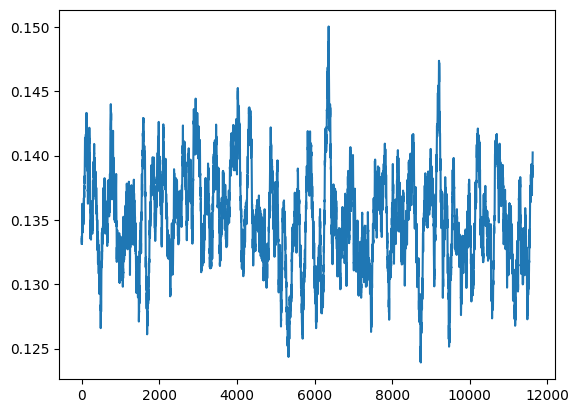

In [ ]:
import numpy as np
def smooth(x, window=100):
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.plot(smooth(train_losses), label="Smoothed Train Loss")

In [ ]:
import torch
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler
from transformers import CLIPTokenizer, CLIPTextModel
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ✅ Device
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [ ]:
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet").to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

In [ ]:
model_path = "/content/drive/MyDrive/GenieVision/unet_epoch_4.pt"  # update path as needed
# model_path = "/content/unet_epoch_3.pt"
unet.load_state_dict(torch.load(model_path, map_location=device))
unet.eval()

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

In [ ]:
# ✅ Load VAE Decoder
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae").to(device).eval()

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

In [ ]:
# ✅ Load CLIP (ViT-L/14)
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device).eval()

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

In [ ]:
# ✅ Noise Scheduler
scheduler = DDPMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(50)

In [ ]:
def generate_image_from_prompt(prompt, unet, vae, tokenizer, text_encoder, scheduler, device, guidance_scale=7.5, save_dir="generated_images"):
    os.makedirs(save_dir, exist_ok=True)

    # ✅ Encode text
    with torch.no_grad():
        cond_tokens = tokenizer([prompt], padding="max_length", truncation=True, return_tensors="pt").to(device)
        cond_embed = text_encoder(**cond_tokens).last_hidden_state
        cond_embed = cond_embed / cond_embed.norm(dim=-1, keepdim=True)

        uncond_embed = torch.zeros_like(cond_embed).to(device)
        text_embed = torch.cat([uncond_embed, cond_embed], dim=0)  # [2, 77, 768]

    # ✅ Start from random noise
    latent = torch.randn(1, 4, 32, 32).to(device)

    # 🔁 Denoising
    for t in scheduler.timesteps:
        latent_in = latent.repeat(2, 1, 1, 1)
        with torch.no_grad():
            noise_pred = unet(latent_in, t, encoder_hidden_states=text_embed).sample
        noise_pred_uncond, noise_pred_cond = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
        latent = scheduler.step(noise_pred, t, latent).prev_sample

    # ✅ Decode to image
    with torch.no_grad():
        decoded = vae.decode(latent / 0.18215).sample

    # ✅ Post-process and save
    image = to_pil_image(decoded.squeeze().clamp(-1, 1) * 0.5 + 0.5)
    image_path = os.path.join(save_dir, f"{prompt.replace(' ', '_')[:40]}.png")
    image.save(image_path)
    print(f"🖼️ Saved: {image_path}")

    return image


🖼️ Saved: generated_images/A_KITCHEN_WITH_A_SINK_AND_APPLIANCES.png


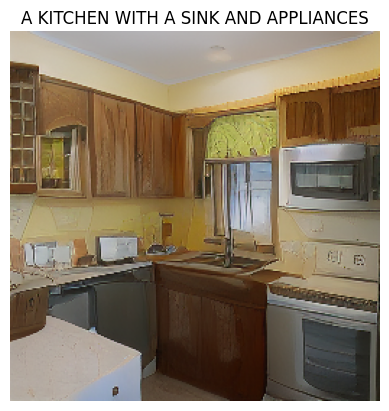

In [ ]:
prompt = "A KITCHEN WITH A SINK AND APPLIANCES"
img = generate_image_from_prompt(
    prompt=prompt,
    unet=unet,
    vae=vae,
    tokenizer=tokenizer,
    text_encoder=text_encoder,
    scheduler=scheduler,
    device=device,
    guidance_scale=6,
)

plt.imshow(img)
plt.axis("off")
plt.title(prompt)
plt.show()

In [ ]:
with open("/content/coco_val_captions_cleaned.json", "r") as f:
    valdata = json.load(f)

In [ ]:
sum("forest" in item["caption"].lower() for item in annotations)

1803

In [ ]:
prompt_file = "coco_val_cleaned_verified.json"
output_dir = "generated_1k"
os.makedirs(output_dir, exist_ok=True)

# ✅ Load 1000 prompts
with open(prompt_file, "r") as f:
    val_data = json.load(f)

sampled_prompts = [entry["caption"] for entry in val_data[:1000]]

In [ ]:
prompt_image_map = []
guidance_scale = 5

In [ ]:

for i, prompt in enumerate(tqdm(sampled_prompts, desc="Generating")):
    try:
        # Encode text
        tokens = tokenizer([prompt], padding="max_length", truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            cond_embed = text_encoder(**tokens).last_hidden_state
            cond_embed = cond_embed / cond_embed.norm(dim=-1, keepdim=True)
            uncond_embed = torch.zeros_like(cond_embed).to(device)
            text_embed = torch.cat([uncond_embed, cond_embed], dim=0)

        # Noise
        latent = torch.randn(1, 4, 32, 32).to(device)

        # Denoising loop
        for t in scheduler.timesteps:
            latent_in = latent.repeat(2, 1, 1, 1)
            with torch.no_grad():
                noise_pred = unet(latent_in, t, encoder_hidden_states=text_embed).sample
            noise_pred_uncond, noise_pred_cond = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
            latent = scheduler.step(noise_pred, t, latent).prev_sample

        # Decode image
        with torch.no_grad():
            decoded = vae.decode(latent / 0.18215).sample

        image = to_pil_image(decoded.squeeze().clamp(-1, 1) * 0.5 + 0.5)
        filename = f"gen_{i:04d}.png"
        image_path = os.path.join(output_dir, filename)
        image.save(image_path)

        # Save mapping
        prompt_image_map.append({"filename": filename, "caption": prompt})

    except Exception as e:
        print(f"❌ Error with prompt {i}: {e}")
        continue

# ✅ Save mapping file
with open(os.path.join(output_dir, "captions.json"), "w") as f:
    json.dump(prompt_image_map, f, indent=2)

print("✅ Generation complete and metadata saved.")

Generating: 100%|██████████| 1000/1000 [36:59<00:00,  2.22s/it]

✅ Generation complete and metadata saved.


In [ ]:
import torch
import clip
from PIL import Image
from tqdm import tqdm

# Load CLIP model (ViT-L/14)
clip_model, clip_preprocess = clip.load("ViT-L/14", device="cuda")
clip_model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)


In [ ]:
def compute_clip_score(img_path, prompt, model, preprocess, device="cuda"):
    try:
        image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
        text = clip.tokenize([prompt]).to(device)

        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(text)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        score = torch.cosine_similarity(image_features, text_features).item()
        return score
    except Exception as e:
        print(f"❌ Failed on {img_path}: {e}")
        return None

In [ ]:
import json
import os

# Load captions
with open("generated_1k/captions.json", "r") as f:
    data = json.load(f)

clip_scores = []

for item in tqdm(data, desc="CLIP Scoring"):
    prompt = item["caption"]
    path = os.path.join("generated_1k", item["filename"])
    score = compute_clip_score(path, prompt, clip_model, clip_preprocess)
    if score is not None:
        clip_scores.append(score)

# Summary
import numpy as np
print(f"\n🔤 Average CLIP Score: {np.mean(clip_scores):.4f}")
print(f"📉 Min: {np.min(clip_scores):.4f}, 📈 Max: {np.max(clip_scores):.4f}")

CLIP Scoring: 100%|██████████| 1000/1000 [00:32<00:00, 30.74it/s]


🔤 Average CLIP Score: 0.2122
📉 Min: 0.0788, 📈 Max: 0.3076


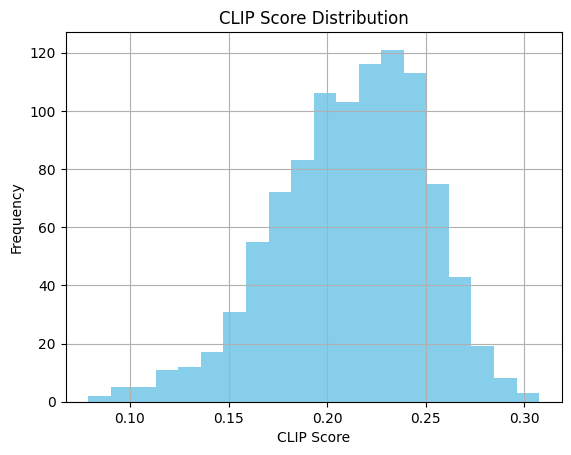

In [ ]:
import matplotlib.pyplot as plt

plt.hist(clip_scores, bins=20, color="skyblue")
plt.title("CLIP Score Distribution")
plt.xlabel("CLIP Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save to Drive (adjust path if needed)
!cp generated_1k.zip /content/drive/MyDrive/

Mounted at /content/drive
cp: cannot stat 'generated_1k.zip': No such file or directory


In [ ]:
import shutil
shutil.make_archive("generated_1k", "zip", "generated_1k")

'/content/generated_1k.zip'

In [ ]:
from google.colab import files
files.download("generated_1k.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

with open("generated_1k/captions.json", "r") as f:
    caption_data = json.load(f)

In [ ]:
# Each item is a dict with score + caption + filename
scored_items = []

for item, score in zip(caption_data, clip_scores):
    scored_items.append({
        "filename": item["filename"],
        "caption": item["caption"],
        "score": score
    })

In [ ]:
top_items = sorted(scored_items, key=lambda x: x["score"], reverse=True)

for i, item in enumerate(top_items[:10]):
    print(f"{i+1}. {item['filename']} | Score: {item['score']:.4f}")
    print(f"   📝 {item['caption']}")

1. gen_0105.png | Score: 0.3076
   📝 A close up of oranges and apples in a bowl.
2. gen_0752.png | Score: 0.2988
   📝 A cat inside of a car during the day.
3. gen_0227.png | Score: 0.2974
   📝 A woman in black sits on a park bench. 
4. gen_0392.png | Score: 0.2961
   📝 An image of a hotel bathroom that is ugly.
5. gen_0888.png | Score: 0.2944
   📝 A giraffe stands underneath a tree on grass.
6. gen_0091.png | Score: 0.2942
   📝 A glass bowl filled with oranges on a table.
7. gen_0706.png | Score: 0.2927
   📝 An image of a bathroom with a sink and mirror 
8. gen_0945.png | Score: 0.2893
   📝 some people sitting behind a line of motorcycles 
9. gen_0685.png | Score: 0.2888
   📝 A person riding a motorcycle in an abandoned stone building
10. gen_0785.png | Score: 0.2883
   📝 a huge group of motor cycles sitting on the street
